1. 为什么需要多智能体系统？

1.1 单一 Agent 的局限性

问题：

❌ 一个 Agent 承担所有任务，职责不清

❌ Prompt 过于复杂，难以维护

❌ 无法实现专业化分工

❌ 难以复用和组合

示例：旅行规划

In [1]:
# 单一 Agent 需要处理所有事情
single_agent_prompt = """
你是一个旅行规划助手，需要：
搜索并推荐航班
搜索并推荐酒店
推荐当地活动
估算总预算
生成行程表
提供天气信息
提供签证信息
... （太多了！）
"""

1.2 多智能体的优势
解决方案：专业化分工

✅ 每个 Agent 专注一个领域

✅ Prompt 简单清晰

✅ 独立开发和测试

✅ 可复用和组合

示例：多 Agent 系统

旅行规划系统
├── 航班专家 Agent（专注航班搜索和推荐）
├── 酒店专家 Agent（专注酒店搜索和推荐）
├── 活动专家 Agent（专注当地活动推荐）
└── 协调器 Agent（整合信息，生成最终方案）

2. Subgraphs: 图中的图
2.1 什么是 Subgraph?
Subgraph（子图） 就是嵌套在主图中的一个完整的图：

子图本身是一个独立的 Graph

子图可以被当作一个节点在主图中使用

子图有自己的 State、Nodes、Edges

概念对比：

普通节点 = 一个函数
Subgraph = 一个完整的图（包含多个节点、边）

2.2 为什么使用 Subgraph?
优势：

✅ 模块化： 复杂逻辑封装成独立的子图

✅ 可复用： 同一个子图可以在多处使用

✅ 清晰： 主图保持简洁，细节在子图中

✅ 独立测试： 每个子图可以单独测试

2.3 基本示例

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

def display_graph(app):
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))

# === 子图 State ===
class SubGraphState(TypedDict):
    number: int       # 与主图共享的 key
    result: int

# === 子图节点 ===
def sub_step1(state: SubGraphState) -> dict:
    """子步骤 1"""
    return {"result": state["number"] * 2}

def sub_step2(state: SubGraphState) -> dict:
    """子步骤 2"""
    return {"result": state["result"] + 10}

# === 创建子图 ===
sub_graph = StateGraph(SubGraphState)
sub_graph.add_node("step1", sub_step1)
sub_graph.add_node("step2", sub_step2)
sub_graph.add_edge(START, "step1")
sub_graph.add_edge("step1", "step2")
sub_graph.add_edge("step2", END)

sub_graph_compiled = sub_graph.compile()

# === 主图 State ===
class MainState(TypedDict):
    number: int        # 与子图共享 → 自动传入子图
    result: int        # 与子图共享 → 自动从子图传回
    final_result: int

# === 主图节点 ===
def prepare_input(state: MainState) -> dict:
    """准备输入"""
    return {"number": state["number"]}

def collect_result(state: MainState) -> dict:
    """收集子图结果"""
    return {"final_result": state["result"]}

# === 创建主图（子图直接作为节点） ===
main_graph = StateGraph(MainState)
main_graph.add_node("prepare", prepare_input)
main_graph.add_node("process", sub_graph_compiled)  # ✅ 直接添加编译后的子图（而非包装函数）
main_graph.add_node("collect", collect_result)

main_graph.add_edge(START, "prepare")
main_graph.add_edge("prepare", "process")
main_graph.add_edge("process", "collect")
main_graph.add_edge("collect", END)

main_app = main_graph.compile()

# === 测试 ===
result = main_app.invoke({"number": 5, "result": 0, "final_result": 0})
print(f"输入: 5")
print(f"子图处理: 5 * 2 + 10 = {result['final_result']}")  # 20

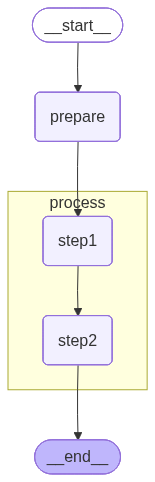

In [6]:
from IPython.display import Image, display

def display_graph(app):
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))  # xray=True 展开子图细节

display_graph(main_app)

2.4 State 映射
问题：主图和子图的 State 通常不同，如何传递数据？

解决方案：State 映射函数

In [8]:
from typing import TypedDict

# === 主图 State ===
class ParentState(TypedDict):
    user_query: str
    search_results: list
    final_answer: str

# === 子图 State ===
class SearchSubgraphState(TypedDict):
    query: str
    results: list

# === 映射函数 ===

def map_input_to_subgraph(parent_state: ParentState) -> SearchSubgraphState:
    """主图 -> 子图：映射输入"""
    return {
        "query": parent_state["user_query"],
        "results": []
    }

def map_output_from_subgraph(
    parent_state: ParentState,
    subgraph_state: SearchSubgraphState
) -> dict:
    """子图 -> 主图：映射输出"""
    return {
        "search_results": subgraph_state["results"]
    }

# === 使用映射的节点 ===

def search_node(state: ParentState) -> dict:
    """使用子图进行搜索"""

    # 1. 映射输入
    sub_input = map_input_to_subgraph(state)

    # 2. 调用子图
    sub_result = search_subgraph.invoke(sub_input)

    # 3. 映射输出
    return map_output_from_subgraph(state, sub_result)

3. 多智能体协作模式3.1 模式 1：顺序协作 (Sequential)特点： Agent 按顺序执行，每个 Agent 的输出是下一个 Agent 的输入。Agent A $\rightarrow$ Agent B $\rightarrow$ Agent C $\rightarrow$ 结果示例：文档处理流水线

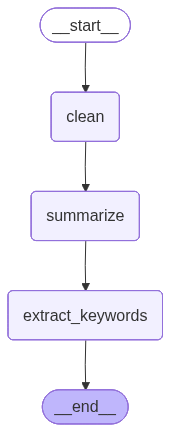

{'raw_text': '这是一段        需要处理的        文本...', 'cleaned_text': '这是一段 需要处理的 文本...', 'summary': '摘要: 这是一段 需要处理的 文本......', 'keywords': ['关键词1', '关键词2', '关键词3']}


In [9]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class DocumentState(TypedDict):
    raw_text: str
    cleaned_text: str
    summary: str
    keywords: list

# Agent 1: 清理文本
def cleaning_agent(state: DocumentState) -> dict:
    """清理文本 Agent"""
    raw = state["raw_text"]
    # 移除多余空格、特殊字符等
    cleaned = " ".join(raw.split())
    return {"cleaned_text": cleaned}

# Agent 2: 生成摘要
def summary_agent(state: DocumentState) -> dict:
    """摘要 Agent"""
    text = state["cleaned_text"]
    # 使用 LLM 生成摘要
    summary = f"摘要: {text[:100]}..."
    return {"summary": summary}

# Agent 3: 提取关键词
def keyword_agent(state: DocumentState) -> dict:
    """关键词提取 Agent"""
    text = state["cleaned_text"]
    # 使用 LLM 或 NLP 工具提取关键词
    keywords = ["关键词1", "关键词2", "关键词3"]
    return {"keywords": keywords}

# 构建顺序流水线
sequential_graph = StateGraph(DocumentState)
sequential_graph.add_node("clean", cleaning_agent)
sequential_graph.add_node("summarize", summary_agent)
sequential_graph.add_node("extract_keywords", keyword_agent)

sequential_graph.add_edge(START, "clean")
sequential_graph.add_edge("clean", "summarize")
sequential_graph.add_edge("summarize", "extract_keywords")
sequential_graph.add_edge("extract_keywords", END)

sequential_app = sequential_graph.compile()
display_graph(sequential_app)

# 测试
result = sequential_app.invoke({
    "raw_text": "这是一段        需要处理的        文本...",
    "cleaned_text": "",
    "summary": "",
    "keywords": []
})
print(result)

The text in the image is as follows:

3.2 模式 2：并行协作 (Parallel)

特点： 多个 Agent 同时执行，互不依赖。
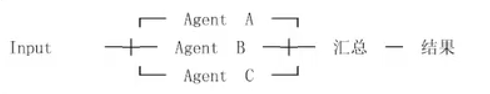
示例：多角度分析

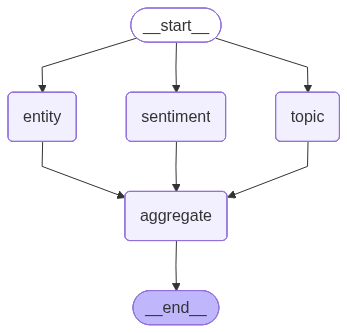

In [10]:
from operator import add

class AnalysisState(TypedDict):
    content: str
    sentiment_analysis: str
    topic_analysis: str
    entity_analysis: str
    all_analyses: Annotated[list, add]

# 并行的 Agent
def sentiment_agent(state: AnalysisState) -> dict:
    """情感分析 Agent"""
    result = "情感: 正面"
    return {
        "sentiment_analysis": result,
        "all_analyses": [{"type": "sentiment", "result": result}]
    }

def topic_agent(state: AnalysisState) -> dict:
    """主题分析 Agent"""
    result = "主题: 技术"
    return {
        "topic_analysis": result,
        "all_analyses": [{"type": "topic", "result": result}]
    }

def entity_agent(state: AnalysisState) -> dict:
    """实体提取 Agent"""
    result = "实体: 公司名、人名"
    return {
        "entity_analysis": result,
        "all_analyses": [{"type": "entity", "result": result}]
    }

def aggregate_results(state: AnalysisState) -> dict:
    """汇总结果"""
    print("\n汇总所有分析结果: ")
    for analysis in state["all_analyses"]:
        print(f" - {analysis['type']}: {analysis['result']}")
    return {}

# 构建并行图
parallel_graph = StateGraph(AnalysisState)

# 添加并行节点
parallel_graph.add_node("sentiment", sentiment_agent)
parallel_graph.add_node("topic", topic_agent)
parallel_graph.add_node("entity", entity_agent)
parallel_graph.add_node("aggregate", aggregate_results)

# 从 START 到所有分析节点 (并行)
parallel_graph.add_edge(START, "sentiment")
parallel_graph.add_edge(START, "topic")
parallel_graph.add_edge(START, "entity")

# 所有分析完成后汇总
parallel_graph.add_edge("sentiment", "aggregate")
parallel_graph.add_edge("topic", "aggregate")
parallel_graph.add_edge("entity", "aggregate")

parallel_graph.add_edge("aggregate", END)

parallel_app = parallel_graph.compile()

display_graph(parallel_app)